### This file test the RePercENT model on synthetic data

In [43]:
import sys
import os

sys.path.append(os.getcwd())
# append the root directory to the sys.path

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Define imports here

In [44]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from src.utils.synthetic_dataset import GenerateData, MultimodalDataset
from src.utils.helpers import linear_probe, extract_latents_and_labels, plot_confusion_matrix, non_linear_probe
from src.models.repercent import RePercENT, DisenLoss
import math
from tqdm.notebook import tqdm
from torch.utils.data import random_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from training.train_repercent import make_model, split_dataset, calculate_linear_probe_acc
from training.train_jointopt_2m import make_model_jointopt
import numpy as np
import yaml

In [45]:
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Read config files

In [69]:
# Read the configuration files for data
data_config_path = os.path.join(base_dir, "configs", "data", "synthetic_data_4m.yaml")
with open(data_config_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Read the configuration files for training
training_config_path = os.path.join(base_dir, "configs", "training", "train_synthetic_4m.yaml")
with open(training_config_path, 'r') as f:
    training_config = yaml.safe_load(f)

### Create a dataset for train / test

In [70]:

def create_dataset_synth(data_config):
    '''
    Create synthetic dataset based on the data configuration and save it to the specified path.
    Args:
        data_config: Configuration dictionary for the data.
    '''
    gen_data = GenerateData(N_data= data_config["create_data"]["N_data"], trans_type= data_config["create_data"]["trans_type"], latent_dim= data_config["create_data"]["latent_dim"], M = data_config["create_data"]["M"])
    gen_data.create_dataset(dist= data_config["create_data"]["dist"], ts= data_config["create_data"]["ts"], gammas= data_config["create_data"]["gammas"], normalize= data_config["create_data"]["normalize"], sigma= data_config["create_data"]["sigma"])
    dataset = MultimodalDataset(total_data= gen_data.dataset_dict['total_data'], labels_u= gen_data.dataset_dict['labels_u'], labels_s= gen_data.dataset_dict['labels_s'])

    return dataset


dataset = create_dataset_synth(data_config)
train_dataset, test_dataset = split_dataset(dataset, test_size= training_config["training"]["test_size"])
train_dataloader = DataLoader(train_dataset, batch_size= training_config["training"]["batch_size"], shuffle= True)
test_dataloader = DataLoader(test_dataset, batch_size= training_config["training"]["batch_size"], shuffle= False)

In [71]:
for batch in train_dataloader:
    print(batch)
    break

[[tensor([[[-0.4179, -0.0171, -0.5598,  ...,  0.2083,  0.0481, -0.0501],
         [-0.4181, -0.0181, -0.3782,  ..., -0.0244, -0.0388,  0.0055],
         [-0.2193, -0.1066,  0.6376,  ...,  0.0336, -0.0096, -0.0408],
         [-0.3947, -0.0712,  0.6998,  ...,  0.0633, -0.0429,  0.0125],
         [ 0.0727, -0.2194, -0.6264,  ..., -0.2172,  0.0246, -0.0330]],

        [[-0.0838,  0.0158, -0.3749,  ...,  0.2977,  0.0654,  0.0200],
         [-0.1036,  0.0207, -0.3132,  ..., -0.0431, -0.0653, -0.0027],
         [-0.0461,  0.1034,  0.4478,  ...,  0.0503, -0.0137,  0.0170],
         [-0.0929,  0.0773,  0.5500,  ...,  0.1062, -0.0684, -0.0058],
         [ 0.0150,  0.2084, -0.4310,  ..., -0.3189,  0.0344,  0.0135]],

        [[-0.0467,  0.0403, -0.1412,  ...,  0.2291,  0.2854,  0.4921],
         [-0.0551,  0.0501, -0.1125,  ..., -0.0317, -0.2714, -0.0635],
         [-0.0179,  0.1828,  0.1173,  ...,  0.0269, -0.0417,  0.2925],
         [-0.0447,  0.1698,  0.1789,  ...,  0.0706, -0.2578, -0.1245],


### Initialize model & load pretrained weights

In [95]:
model_type = "jointopt"  # Options: "repercent", "jointopt"
# Read the configuration files for the model
model_config_path = os.path.join(base_dir, "configs", "model", f"{model_type}_4m.yaml")
with open(model_config_path, 'r') as f:
    model_config = yaml.safe_load(f)
match model_type:
    case "repercent":
        # Define the disentangled encoders
        disenEncoders = [make_model(model_config, data_config, modality= m+1, M= data_config["create_data"]["M"]) for m in range(data_config["create_data"]["M"])]

        # Define the RePercENT model
        model= RePercENT(M= data_config["create_data"]["M"], disenEncoder= disenEncoders, disen_mapping= model_config["repercent"]["disen_mapping"]).to(device)
    case "jointopt":
        model = make_model_jointopt(model_config, data_config).to(device)
    case _:
        raise ValueError(f"Unknown model type: {model_type}")

disen_loss = DisenLoss(alpha= training_config["disen_loss"]["alpha"], lmd=training_config["disen_loss"]["lmd"], lmd_end_value= training_config["disen_loss"]["lmd_end_value"], M= data_config["create_data"]["M"])
optimizer = torch.optim.Adam(model.parameters(), lr=training_config["optimizer"]["lr"], weight_decay= training_config["optimizer"]["weight_decay"])  

In [96]:
for _iter in range(training_config["training"]["n_epochs"]):
    epoch_loss = 0.0
    epoch_ortho_loss = 0.0
    epoch_unique_loss = 0.0
    epoch_shared_loss = 0.0
    
    model.train()
    print(f"Num of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
    print(f"----- Epoch: {_iter + 1} / {training_config['training']['n_epochs']} -----")
    # Training phase
    for batch_idx, (X, labels_u, labels_s) in enumerate(train_dataloader):
        temp_b = X[0].shape[0]
        X = [X[m].to(device) for m in range(len(X))]

        # Augment data
        X_aug = [GenerateData.augment_data(X[m], aug_type="random") for m in range(len(X))]
        
        out = model(X)
        out_aug = model(X_aug)
        
        loss, loss_logs = disen_loss(out, out_aug)
        
        optimizer.zero_grad(set_to_none= True)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() / temp_b
        epoch_ortho_loss += loss_logs['ortho'] / temp_b
        epoch_unique_loss += loss_logs['unique'] / temp_b
        epoch_shared_loss += loss_logs['shared'] / temp_b
    print(f"Train Loss (x 100): {100 * epoch_loss / (batch_idx + 1):.4f} | Ortho Loss (x 100): {100 * epoch_ortho_loss / (batch_idx + 1):.4f} | \
        Unique Loss (x 100): {100 * epoch_unique_loss / (batch_idx + 1):.4f} | Shared Loss (x 100): {100 * epoch_shared_loss / (batch_idx + 1):.4f}")
    # train_data_dict = extract_latents_and_labels(model, train_dataloader, device)
    # val_data_dict = extract_latents_and_labels(model, test_dataloader, device)
    # components = list(train_data_dict['Labels_U'].keys()) + list(train_data_dict['Labels_S'].keys())
    
    # linear_probe_acc = calculate_linear_probe_acc(train_data_dict, val_data_dict)
    # plot_confusion_matrix(linear_probe_acc, labels= components, components= components)
    # break

Num of parameters: 743784
----- Epoch: 1 / 30 -----


KeyboardInterrupt: 

In [77]:
train_data_dict = extract_latents_and_labels(model, train_dataloader, device)
val_data_dict = extract_latents_and_labels(model, test_dataloader, device)
components = list(train_data_dict['Labels_U'].keys()) + list(train_data_dict['Labels_S'].keys())

linear_probe_acc = calculate_linear_probe_acc(train_data_dict, val_data_dict)

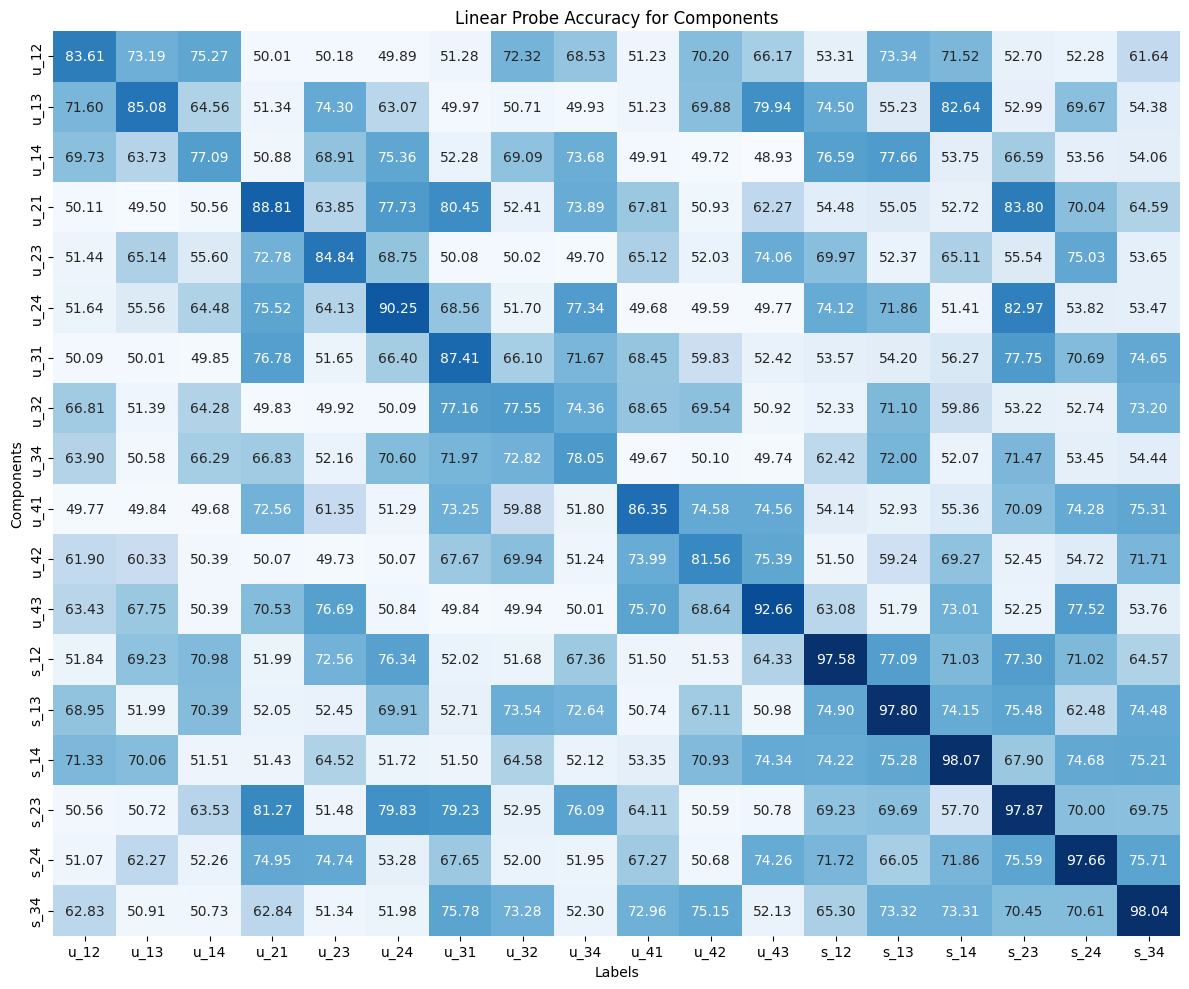

In [78]:
import matplotlib.pyplot as plt

plot_confusion_matrix(linear_probe_acc, labels= components, components= components)
plt.close("all")

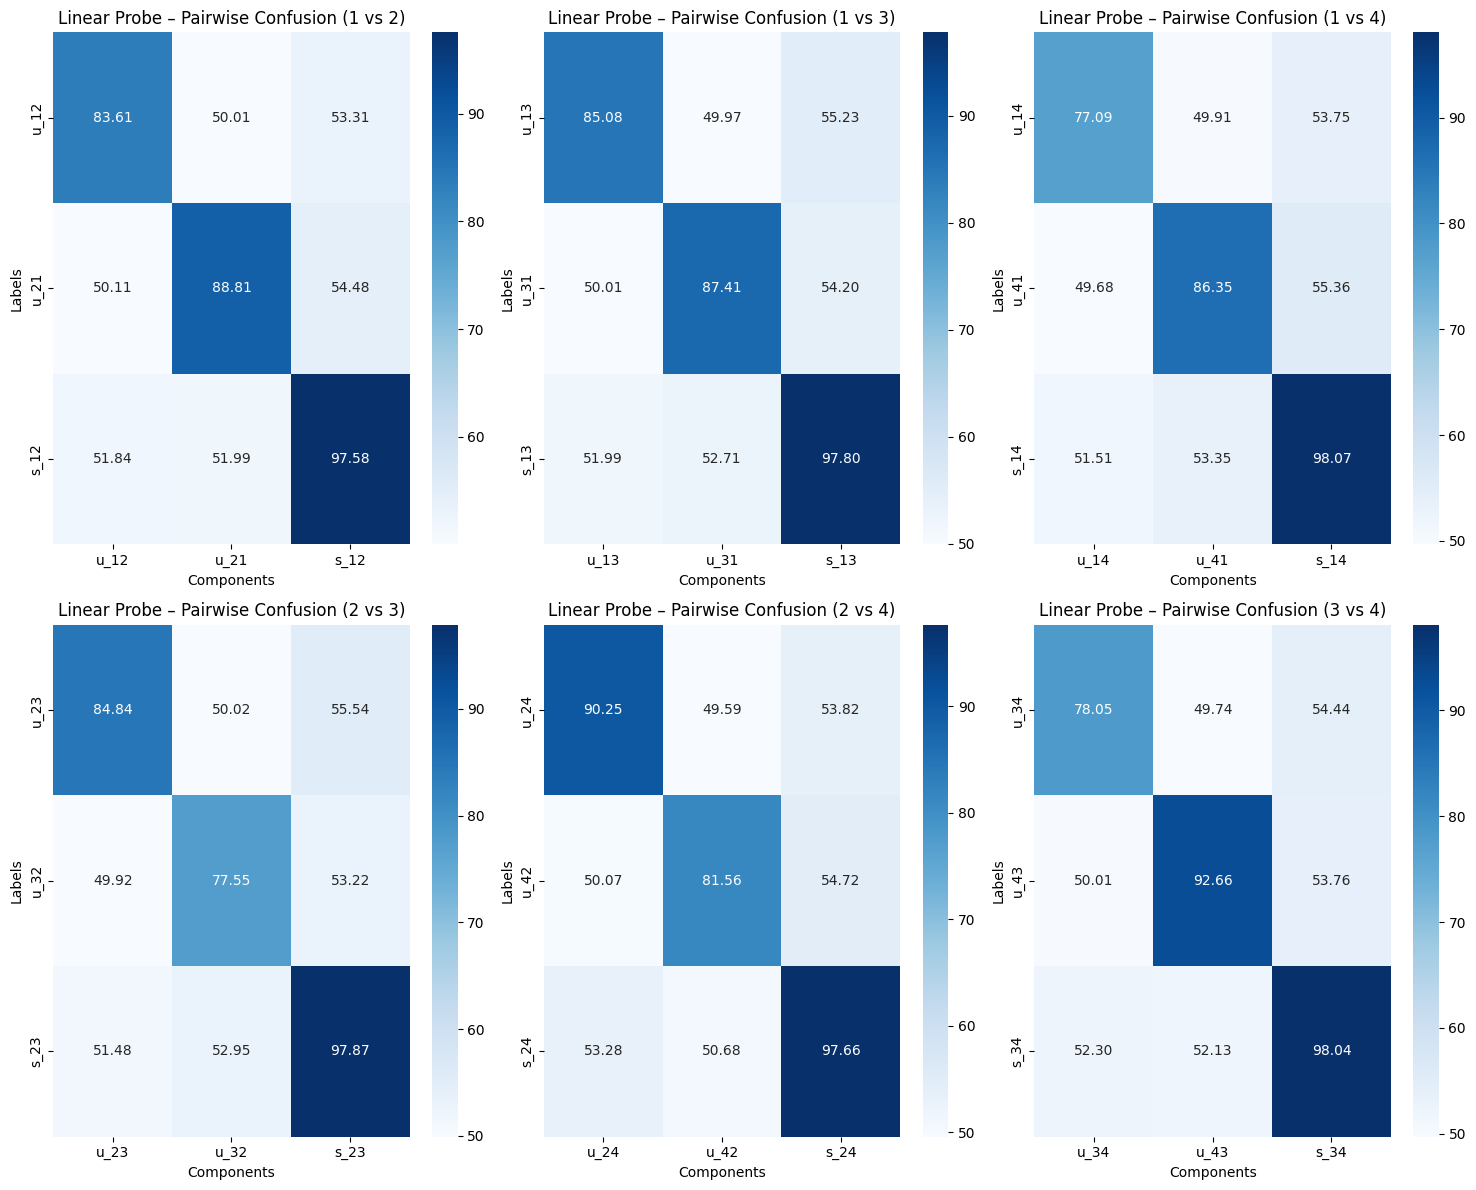

In [80]:
from src.utils.helpers import plot_pairwise_confusion_matrices
from itertools import combinations
M = 4

plot_pairwise_confusion_matrices(linear_probe_acc, M= 4, components= components, pairs = list(combinations(range(M), 2)))
plt.close("all")

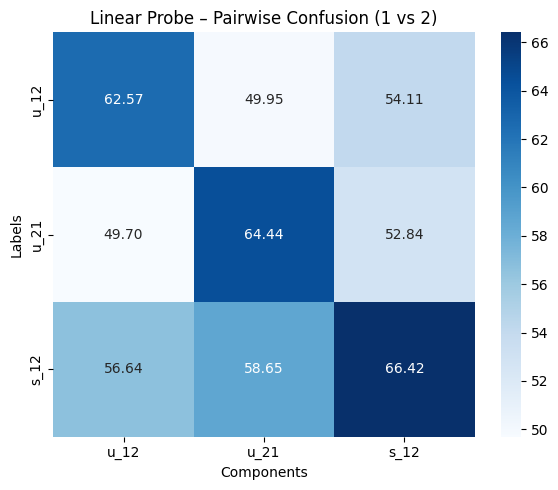

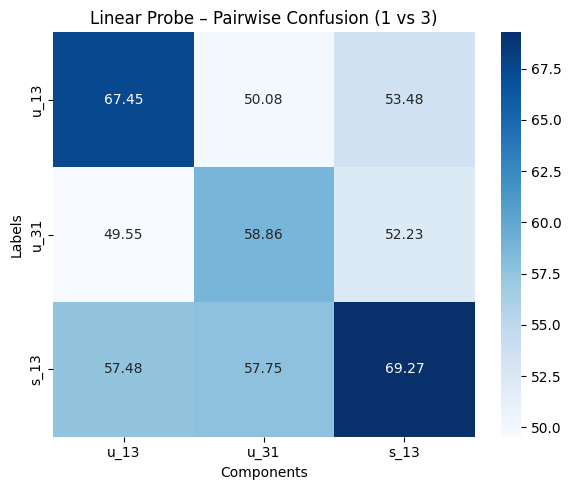

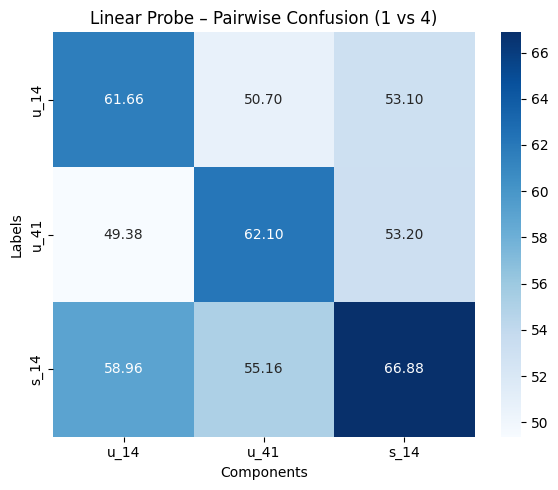

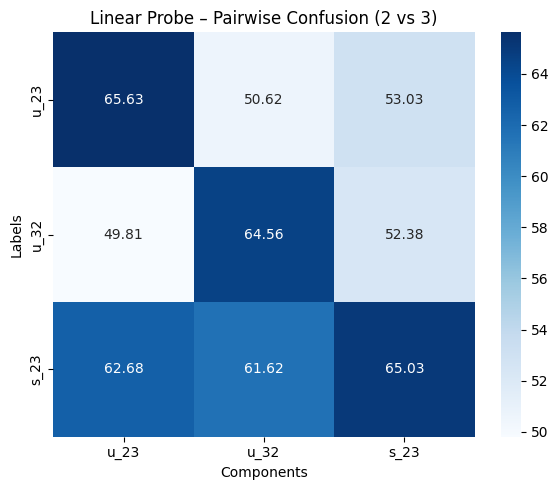

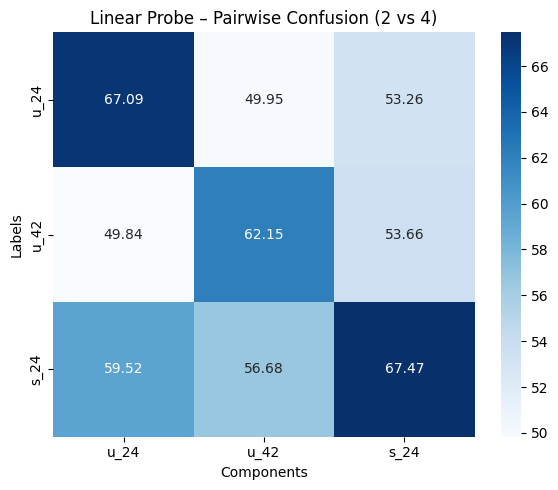

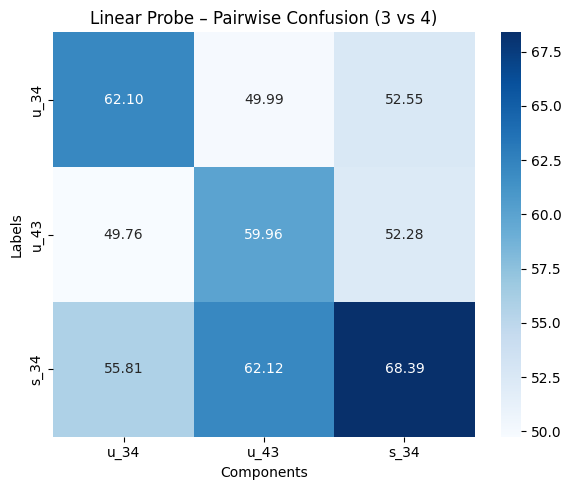

In [57]:
def parse_pair(key):
    # "u_12" or "s_23"
    i = int(key[2]) - 1
    j = int(key[3]) - 1
    return i, j

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

def plot_pairwise_confusion_matrices(linear_probe_acc, M, figsize=(5, 4)):
    """
    Plot M*(M-1)/2 confusion matrices, one per modality pair.

    Rows: labels
    Columns: components
    Values: linear probe accuracy
    """

    # reconstruct component & label keys (same set)
    label_keys = list(linear_probe_acc.keys())
    comp_keys = label_keys.copy()

    # build full accuracy matrix (rows=labels, cols=components)
    A = np.stack([linear_probe_acc[k] for k in label_keys], axis=0)

    # all unordered modality pairs
    pairs = list(combinations(range(M), 2))

    for (i, j) in pairs:
        pair_name = f"{i+1} vs {j+1}"

        # columns: u_ij, u_ji, s_ij
        col_keys = [f"u_{i+1}{j+1}", f"u_{j+1}{i+1}", f"s_{i+1}{j+1}"]
        col_idx = [comp_keys.index(k) for k in col_keys]

        # rows: same pairwise labels
        row_keys = col_keys
        row_idx = [label_keys.index(k) for k in row_keys]

        submat = A[np.ix_(row_idx, col_idx)]

        plt.figure(figsize=figsize)
        sns.heatmap(
            submat,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=col_keys,
            yticklabels=row_keys,
            cbar=True,
        )
        plt.title(f"Linear Probe – Pairwise Confusion ({pair_name})")
        plt.xlabel("Components")
        plt.ylabel("Labels")
        plt.tight_layout()
        plt.show()
plot_pairwise_confusion_matrices(linear_probe_acc, M= data_config["create_data"]["M"], figsize=(6, 5))

In [ ]:
model.eval()
    
with torch.no_grad():
    for batch_idx, (X, labels_u, labels_s) in enumerate(train_dataloader):
        temp_b = X[0].shape[0]
        X = [X[m].to(device) for m in range(len(X))]

        # Augment data
        X_aug = [GenerateData.augment_data(X[m], aug_type="random") for m in range(len(X))]
        
        out = model(X)
        out_aug = model(X_aug)
        print(out['U'].shape)
        break

torch.Size([1024, 3, 3, 16])


### Calculate linear probing accuracy

In [ ]:
# Linear probing evaluation
print("Extracting latents from train and test datasets...")

# Extract latents and labels from train and test sets
train_data_dict = extract_latents_and_labels(model, train_dataloader, device)
test_data_dict = extract_latents_and_labels(model, test_dataloader, device)

Extracting latents from train and test datasets...


In [ ]:
linear_probe_acc = {"u_12": np.zeros(3), "u_21": np.zeros(3), "s": np.zeros(3)}
for i, label in enumerate(['labels_1', 'labels_2', 'labels_s']):
    print(f"\nEvaluating disentanglement for {label}...")
    
    # Unique component of modality 1
    linear_probe_acc["u_12"][i] = linear_probe(
        train_data_dict['u_12'], train_data_dict[label],
        test_data_dict['u_12'], test_data_dict[label]
    )
    print(f"  Unique component of modality 1 accuracy: {linear_probe_acc['u_12'][i]:.2f}%")
    # Unique component of modality 2
    linear_probe_acc["u_21"][i] = linear_probe(
        train_data_dict['u_21'], train_data_dict[label],
        test_data_dict['u_21'], test_data_dict[label]
    )
    print(f"  Unique component of modality 2 accuracy: {linear_probe_acc['u_21'][i]:.2f}%")
    # Shared component from modality 2
    linear_probe_acc["s"][i] = linear_probe(
        np.concatenate((train_data_dict['s_21'], train_data_dict['s_12']), axis= -1), train_data_dict[label],
        np.concatenate((test_data_dict['s_21'], test_data_dict['s_12']), axis= -1), test_data_dict[label]
    )
    print(f"  Shared component accuracy: {linear_probe_acc['s'][i]:.2f}%")
    
input_linear_probe_acc = {"x_12": np.zeros(3), "x_21": np.zeros(3), "xs": np.zeros(3)}
for i, label in enumerate(['labels_1', 'labels_2', 'labels_s']):
    print(f"\nEvaluating input data for {label}...")
    
    # Input data from modality 1
    input_linear_probe_acc["x_12"][i] = linear_probe(
        train_data_dict['x_12'], train_data_dict[label],
        test_data_dict['x_12'], test_data_dict[label]
    )
    print(f"  Input data from modality 1 accuracy: {input_linear_probe_acc['x_12'][i]:.2f}%")
    # Input data from modality 2
    input_linear_probe_acc["x_21"][i] = linear_probe(
        train_data_dict['x_21'], train_data_dict[label],
        test_data_dict['x_21'], test_data_dict[label]
    )
    print(f"  Input data from modality 2 accuracy: {input_linear_probe_acc['x_21'][i]:.2f}%")
    # Shared input data
    input_linear_probe_acc["xs"][i] = linear_probe(
        np.concatenate((train_data_dict['xs_21'], train_data_dict['xs_12']), axis= -1), train_data_dict[label],
        np.concatenate((test_data_dict['xs_21'], test_data_dict['xs_12']), axis= -1), test_data_dict[label]
    )
    print(f"  Shared input data accuracy: {input_linear_probe_acc['xs'][i]:.2f}%")


Evaluating disentanglement for labels_1...
  Unique component of modality 1 accuracy: 71.36%
  Unique component of modality 2 accuracy: 49.30%
  Shared component accuracy: 54.07%

Evaluating disentanglement for labels_2...
  Unique component of modality 1 accuracy: 49.16%
  Unique component of modality 2 accuracy: 80.27%
  Shared component accuracy: 53.35%

Evaluating disentanglement for labels_s...
  Unique component of modality 1 accuracy: 51.19%
  Unique component of modality 2 accuracy: 52.13%
  Shared component accuracy: 91.76%

Evaluating input data for labels_1...
  Input data from modality 1 accuracy: 97.14%
  Input data from modality 2 accuracy: 49.56%
  Shared input data accuracy: 50.01%

Evaluating input data for labels_2...
  Input data from modality 1 accuracy: 50.03%
  Input data from modality 2 accuracy: 95.47%
  Shared input data accuracy: 50.08%

Evaluating input data for labels_s...
  Input data from modality 1 accuracy: 50.16%
  Input data from modality 2 accuracy: 

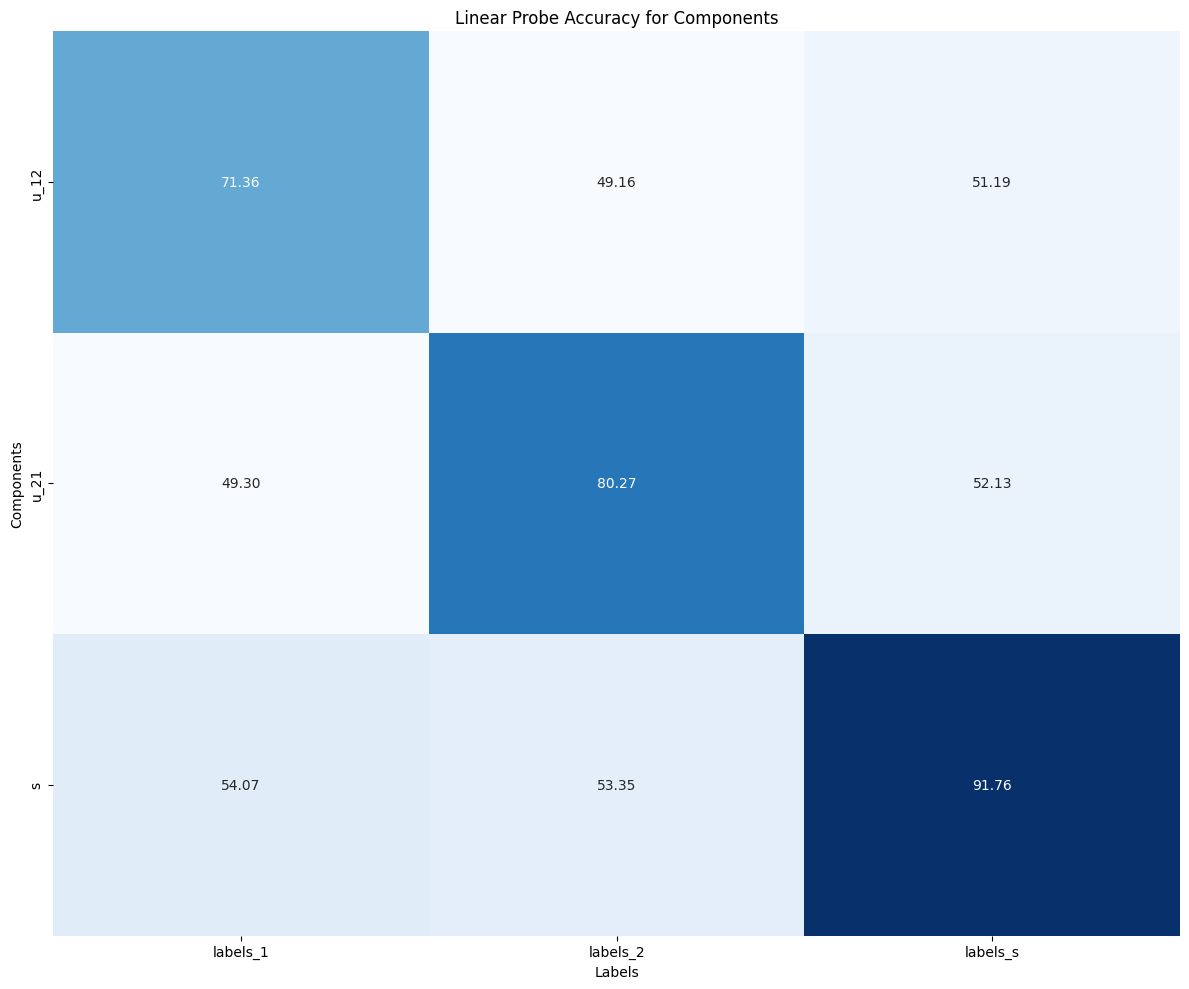

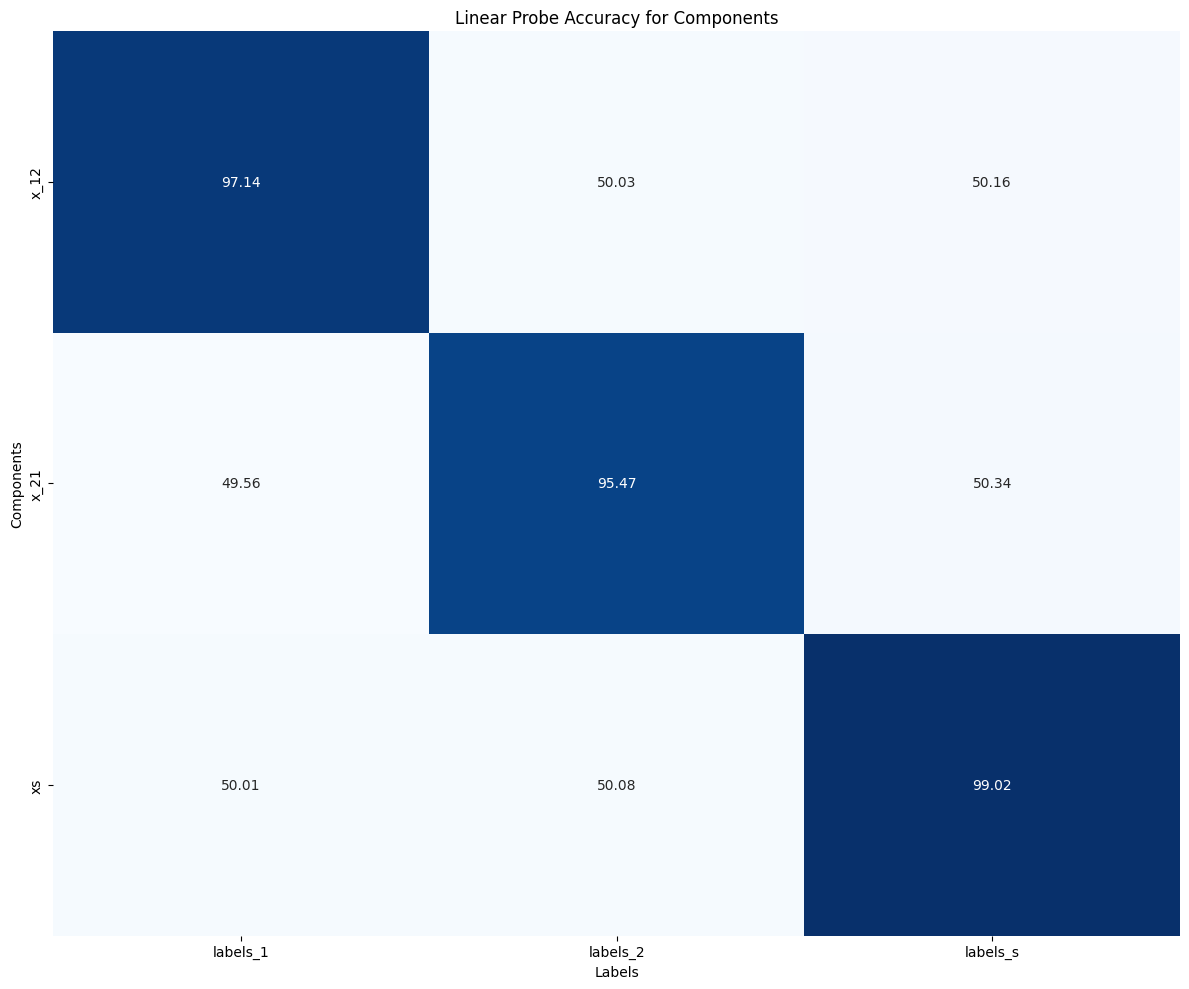

In [ ]:
plot_confusion_matrix(linear_probe_acc)
plot_confusion_matrix(input_linear_probe_acc, components= ['x_12', 'x_21', 'xs'])

### Same but non-linear probing

In [ ]:
non_linear_probe_acc = {"u_12": np.zeros(3), "u_21": np.zeros(3), "s": np.zeros(3)}
for i, label in enumerate(['labels_1', 'labels_2', 'labels_s']):
    print(f"\nEvaluating disentanglement for {label}...")
    
    # Unique component of modality 1
    non_linear_probe_acc["u_12"][i] = non_linear_probe(
        train_data_dict['u_12'], train_data_dict[label],
        test_data_dict['u_12'], test_data_dict[label]
    )
    print(f"  Unique component of modality 1 accuracy: {non_linear_probe_acc['u_12'][i]:.2f}%")
    # Unique component of modality 2
    non_linear_probe_acc["u_21"][i] = non_linear_probe(
        train_data_dict['u_21'], train_data_dict[label],
        test_data_dict['u_21'], test_data_dict[label]
    )
    print(f"  Unique component of modality 2 accuracy: {non_linear_probe_acc['u_21'][i]:.2f}%")
    # Shared component from modality 2
    non_linear_probe_acc["s"][i] = non_linear_probe(
        np.concatenate((train_data_dict['s_21'], train_data_dict['s_12']), axis= -1), train_data_dict[label],
        np.concatenate((test_data_dict['s_21'], test_data_dict['s_12']), axis= -1), test_data_dict[label]
    )
    print(f"  Shared component accuracy: {non_linear_probe_acc['s'][i]:.2f}%")

input_non_linear_probe_acc = {"x_12": np.zeros(3), "x_21": np.zeros(3), "xs": np.zeros(3)}
for i, label in enumerate(['labels_1', 'labels_2', 'labels_s']):
    print(f"\nEvaluating input data for {label}...")
    
    # Input data from modality 1
    input_non_linear_probe_acc["x_12"][i] = non_linear_probe(
        train_data_dict['x_12'], train_data_dict[label],
        test_data_dict['x_12'], test_data_dict[label]
    )
    print(f"  Input data from modality 1 accuracy: {input_non_linear_probe_acc['x_12'][i]:.2f}%")
    # Input data from modality 2
    input_non_linear_probe_acc["x_21"][i] = non_linear_probe(
        train_data_dict['x_21'], train_data_dict[label],
        test_data_dict['x_21'], test_data_dict[label]
    )
    print(f"  Input data from modality 2 accuracy: {input_non_linear_probe_acc['x_21'][i]:.2f}%")
    # Shared input data
    input_non_linear_probe_acc["xs"][i] = non_linear_probe(
        np.concatenate((train_data_dict['xs_21'], train_data_dict['xs_12']), axis= -1), train_data_dict[label],
        np.concatenate((test_data_dict['xs_21'], test_data_dict['xs_12']), axis= -1), test_data_dict[label]
    )
    print(f"  Shared input data accuracy: {input_non_linear_probe_acc['xs'][i]:.2f}%")
    


Evaluating disentanglement for labels_1...
  Unique component of modality 1 accuracy: 73.17%
  Unique component of modality 2 accuracy: 50.18%
  Shared component accuracy: 50.23%

Evaluating disentanglement for labels_2...
  Unique component of modality 1 accuracy: 49.71%
  Unique component of modality 2 accuracy: 64.22%
  Shared component accuracy: 52.08%

Evaluating disentanglement for labels_s...
  Unique component of modality 1 accuracy: 50.72%
  Unique component of modality 2 accuracy: 51.66%
  Shared component accuracy: 82.30%

Evaluating input data for labels_1...
  Input data from modality 1 accuracy: 99.30%
  Input data from modality 2 accuracy: 50.19%
  Shared input data accuracy: 50.06%

Evaluating input data for labels_2...
  Input data from modality 1 accuracy: 49.90%
  Input data from modality 2 accuracy: 99.31%
  Shared input data accuracy: 49.84%

Evaluating input data for labels_s...
  Input data from modality 1 accuracy: 49.29%
  Input data from modality 2 accuracy: 

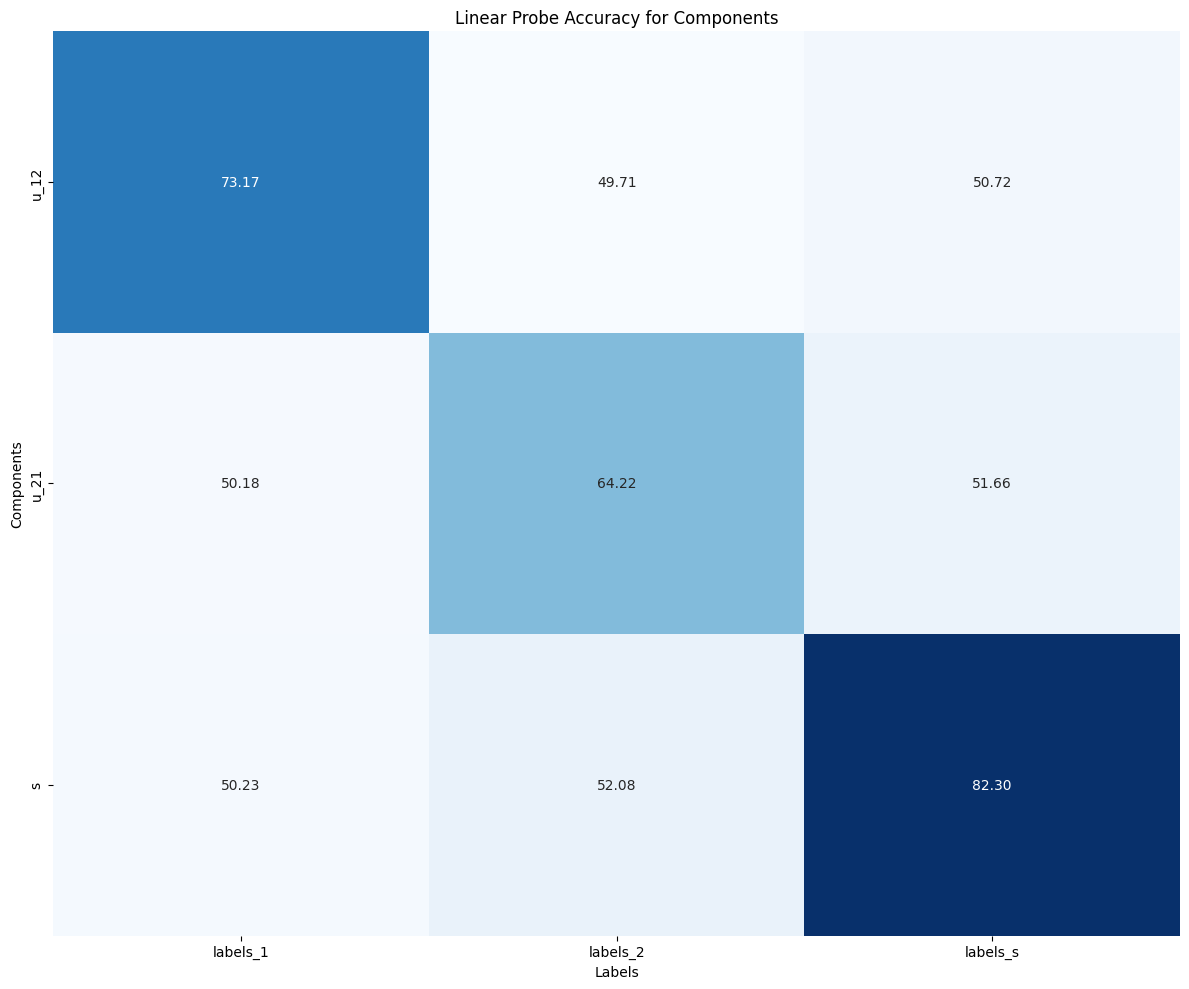

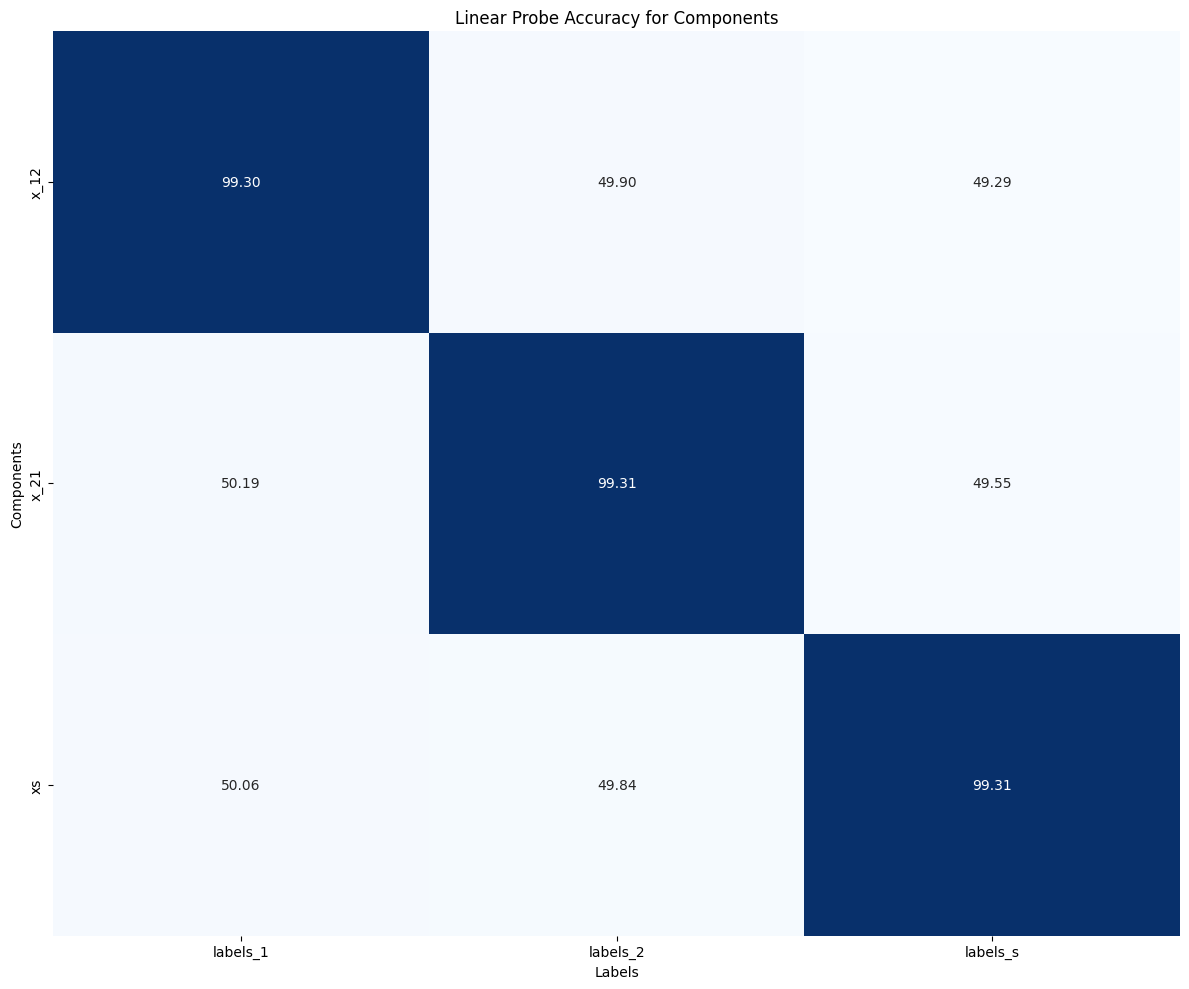

In [ ]:
plot_confusion_matrix(non_linear_probe_acc)
plot_confusion_matrix(input_non_linear_probe_acc, components= ['x_12', 'x_21', 'xs'])

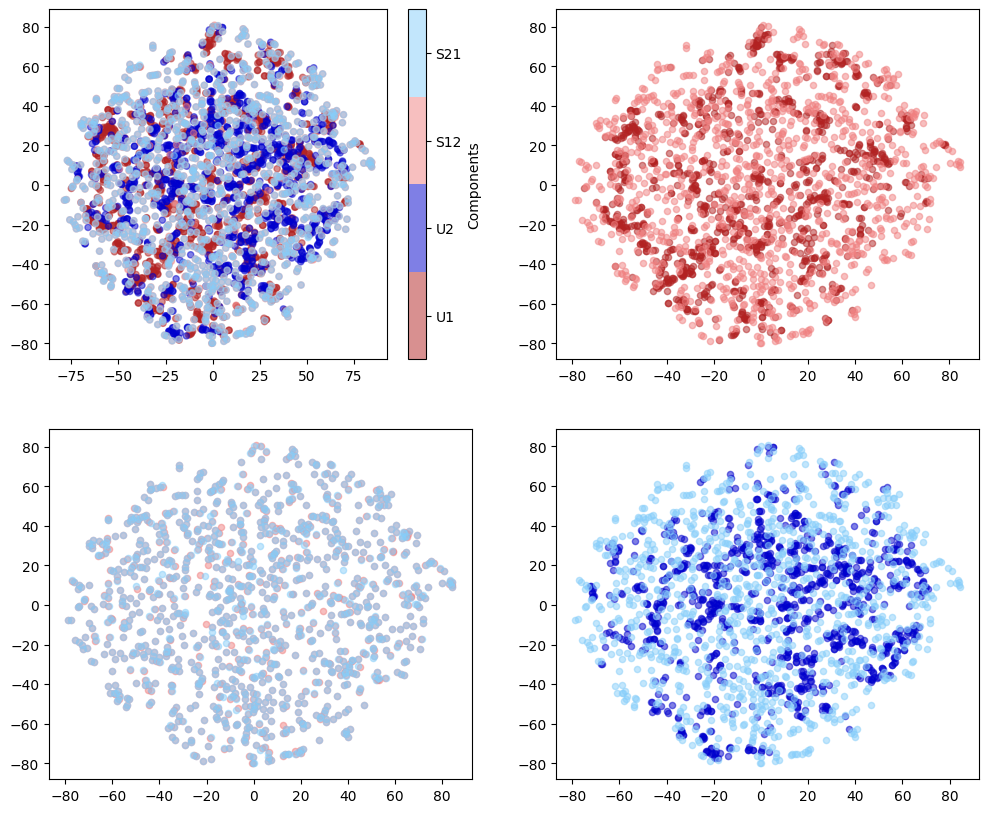

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
import pickle as pkl

# Extract the disentangled components from the trained model
model.eval()


# Use a batch from the dataset for visualization
data_m1_viz, data_m2_viz, _, _, _ = next(iter(test_dataloader))

data_m1_viz = data_m1_viz.to(device)
data_m2_viz = data_m2_viz.to(device)

# Forward pass to extract disentangled components
with torch.no_grad():
    outputs_viz = model(data_m1_viz, data_m2_viz)
    
    # Extract components
    z_1 = outputs_viz['Z1'][0].cpu().numpy()  # Unique component from modality 1
    z_2 = outputs_viz['Z2'][0].cpu().numpy()  # Unique component from modality 2
    s_12 = outputs_viz['Z1'][1].cpu().numpy() # shared component from modality 1
    s_21 = outputs_viz['Z2'][1].cpu().numpy() # shared component from modality 2
    
    size = z_1.shape[0]

    labels = [0] * size + [1] * size + size * [2] + size * [3]
    
    # t-SNE 2D visualization
    # Concatenate all components for t-SNE
    concat = np.concatenate([z_1, z_2, s_12, s_21], axis=0)

    # t-SNE 2D visualization
    best_kl = float('inf')
    
    best_tsne = None
    for i in range(10):
        tsne = TSNE(n_components=2, random_state= i, perplexity=20)
        tsne.fit(concat)
        temp_kl = tsne.kl_divergence_
        if temp_kl < best_kl:
            best_kl = temp_kl
            best_tsne = tsne
    tsne_result = best_tsne.fit_transform(concat)



    fig, ax = plt.subplots(2, 2, figsize=(12, 10))
    colors = ['#b22222', '#0000cd', '#f08080', '#87cefa']  # dark red, light red, dark blue, light blue

    # Create colormap
    cmap = ListedColormap(colors)
    scatter3 = ax[0, 0].scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap= cmap, alpha=0.5, s= 20)

    # Discrete colorbar for four labels
    cbar = fig.colorbar(scatter3, ax=ax[0, 0], ticks=[0, 1, 2, 3], boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5])
    cbar.set_label('Components')
    cbar.set_ticklabels(['U1', 'U2', 'S12', 'S21'])

    ax[0, 1].scatter(tsne_result[:size, 0], tsne_result[:size, 1], c= colors[0], label='U1', alpha=0.5, s=20)
    ax[0, 1].scatter(tsne_result[2*size:3*size, 0], tsne_result[2*size:3*size, 1], c=colors[2], label='S12', alpha=0.5, s=20)

    ax[1, 1].scatter(tsne_result[size:2*size, 0], tsne_result[size:2*size, 1], c= colors[1], label='U2', alpha=0.5, s=20)
    ax[1, 1].scatter(tsne_result[3*size:, 0], tsne_result[3*size:, 1], c=colors[3], label='S21', alpha=0.5, s=20)
    
    ax[1, 0].scatter(tsne_result[2*size:3*size, 0], tsne_result[2*size:3*size, 1], c=colors[2], label='S12', alpha=0.5, s=20)
    ax[1, 0].scatter(tsne_result[3*size:, 0], tsne_result[3*size:, 1], c=colors[3], label='S21', alpha=0.5, s=20)
    plt.show()